# Customer Clustering (Unsupervised)
This notebook segments customers using K-means clustering on scaled RFM features. We'll scale the data, determine optimal k with elbow and silhouette plots, fit the model, assign cluster labels, visualize results, log experiments with MLflow, and save outputs

## 1. Load and Scale RFM Features
Load the RFM DataFrame and scale the features (Recency, Frequency, Monetary) using StandardScaler to ensure equal weighting in clustering

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load RFM features
rfm = pd.read_csv('data/rfm_features.csv')

# Scale RFM features (use numpy array for fitting)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

## 2. Elbow Plot for Optimal K
Compute inertia for k=1 to 10 and plot the elbow curve to identify a potential optimal number of clusters (look for the "elbow" where inertia decreases slow down).

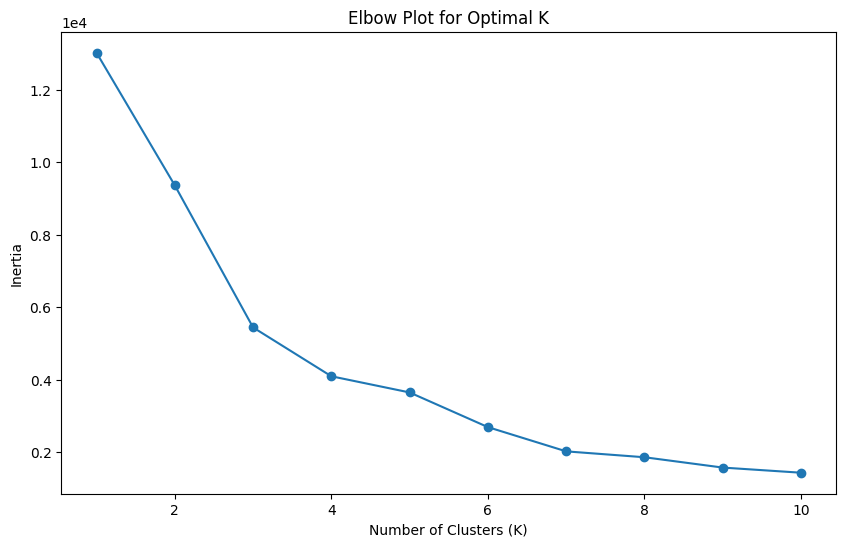

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Elbow plot for optimal k (inertia)
inertia = []
k_range = range(1, 11)
for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(rfm_scaled)
  inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Plot for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.show()

## 3. Silhouette Scores for Different K
Compute silhouette scores for k=2 to 10 (measures cluster cohesion/separation) and plot to help select k (higher score is better, look for peaks).

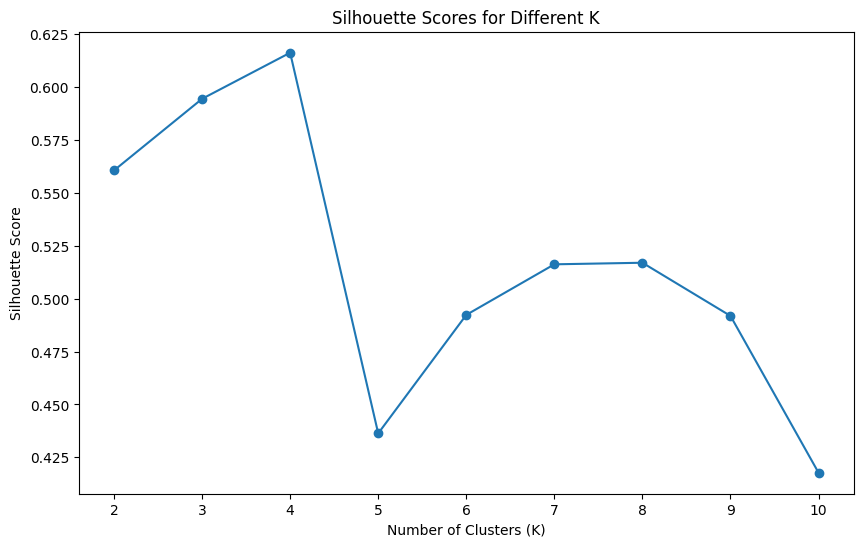

In [3]:
from sklearn.metrics import silhouette_score

# Silhouette scores for k=2 to 10
sil_scores = []
for k in range(2, 11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  clusters = kmeans.fit_predict(rfm_scaled)
  sil_scores.append(silhouette_score(rfm_scaled, clusters))

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), sil_scores, marker='o')
plt.title("Silhouette Scores for Different K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

## 4. Fit K-Means and Assign Cluster Labels
Choose k based on the plots, fit the KMeans model, and add the 'Cluster' labels to the RFM DataFrame.

In [4]:
# Choose k based on plots
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

## 5. Visualize Clusters
Create scatterplots to visualize the clusters (e.g., Recency vs Monetary, Frequency vs Monetary, colored by Cluster) to interpret the segments. 

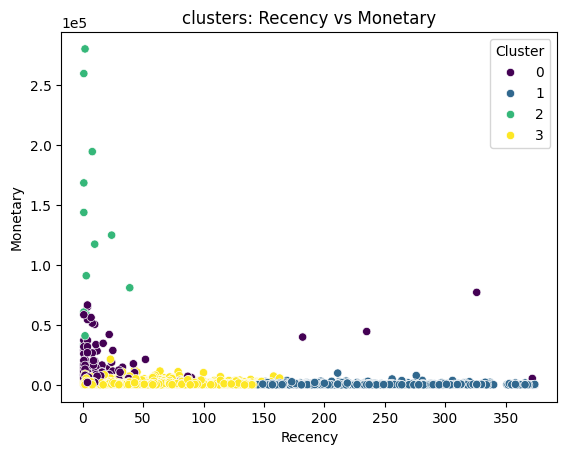

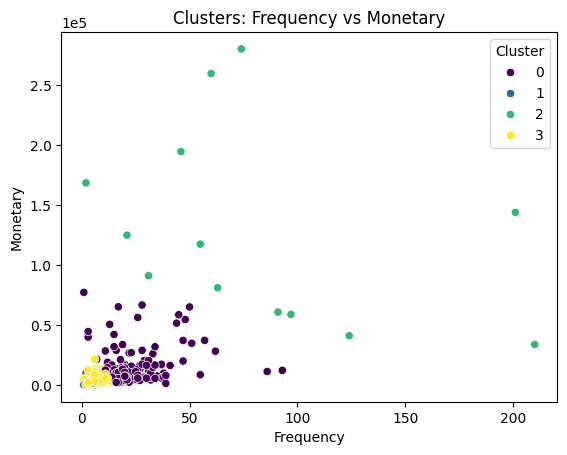

In [5]:
import seaborn as sns

# Visualize clusters (scatterplots)
sns.scatterplot(x='Recency', y='Monetary', hue='Cluster', data=rfm, palette='viridis')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.title("clusters: Recency vs Monetary")
plt.show()

sns.scatterplot(x='Frequency', y='Monetary', hue='Cluster', data=rfm, palette='viridis')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.title("Clusters: Frequency vs Monetary")
plt.show()

## 6. Log Experiment with MLflow
Set up an MLflow experiment, log parameters/metrics (e.g., k, inertia, silhouette), the model, and artifacts (e.g., plots) for tracking.

In [6]:
import mlflow

# Log experiment with MLflow
mlflow.set_experiment("Customer_Clustering")
with mlflow.start_run(run_name="KMeans_RFM_k4"):
    mlflow.log_param("n_clusters", k)
    mlflow.log_metric("inertia", kmeans.inertia_)
    sil = silhouette_score(rfm_scaled, rfm['Cluster'])
    mlflow.log_metric("silhouette_score", sil)
    mlflow.sklearn.log_model(kmeans, "kmeans_model")
    # Save and log plots as artifacts (example for elbow; repeat for others if needed)
    plt.savefig('elbow_plot.png')  # Note: This saves the last active plot; save each plot separately in practice
    mlflow.log_artifact('elbow_plot.png')
    print("MLflow run logged successfully")

2025/09/23 17:47:26 INFO mlflow.tracking.fluent: Experiment with name 'Customer_Clustering' does not exist. Creating a new experiment.
2025/09/23 17:47:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/23 17:47:29 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


MLflow run logged successfully


<Figure size 640x480 with 0 Axes>

## 7. Save Outputs
Save the updated RFM DataFrame with cluster labels as a CSV for use in later days.

In [7]:
# Save RFM with cluster labels
rfm.to_csv('data/rfm_with_clusters.csv', index=False)
print("RFM with clusters saved as 'data/rfm_with_clusters.csv'")

RFM with clusters saved as 'data/rfm_with_clusters.csv'


## 8. Ethical Considerations and Bias Check
Quick check for potential biases (e.g., country-based clustering skew). Visualize cluster distribution by country to spot issues like over-representation.

In [10]:
# Merge clusters back to original data if needed (for bias check)
# Assume df_clean has CustomerID; join on it
df_clean = pd.read_csv('data/clean_online_retail.csv')
df_clean_with_clusters = df_clean.merge(rfm[['CustomerID', 'Cluster']], on='CustomerID', how='left')

# Visualize cluster distribution by top countries (check for bias)
top_countries = df_clean_with_clusters['Country'].value_counts().head(10).index
sns.countplot(x='Clusters', hue='Country', data=df_clean_with_clusters[df_clean_with_clusters['Country'].isin(top_countries)])
plt.title("Cluster Distribution by Top 10 Countries")
plt.show()

# Note: If one country dominates clusters, consider debiasing (e.g., stratified sampling) in future iterations.
print("Ethical note: Watch for biases-e.g., UK may dominate due to dataset skew; adjust features if needed for fairness.")

KeyError: "['CustomerID'] not in index"

## 9. Unit Test with pytest
Add simple unit tests (as per best practices) to verify key functions, like scaling and clustering output shape. Save as 'test/test_clustering.py' and run with pytest.

In [ ]:
def test_scaling(rfm_scaled):
  assert rfm_scaled.shape[1] == 3, "Scaled RFM should have 3 columns"
  assert abs(rfm_scaled.mean()) < 1e-6, "Scaled data should have mean ~0"

def test_clusters(rfm):
  assert 'Cluster' in rfm.columns, "Cluster column missing"
  assert len(rfm['Cluster'].unique()) == 4, "Expected 4 unique clusters"

# To run: in terminal pytest tests/
print("Run pytest in terminal to test; example assertion show above.")